# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/).

**Se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.


## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/)). Para la entrega 2 hay nuevas dependencias, por lo que es importante correr la siguiente celda.

In [ ]:
# Instalación de librerías necesarias
#!pip install jupyter pandas seaborn pillow networkx nltk scikit-learn



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import re
import os

from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import nltk
import matplotlib.patches as mpatches


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

## Lectura de Datos

In [2]:
# DataFrame con todos los discursos:
df_speeches = pd.read_csv('./data/us_2020_election_speeches.csv')
df_speeches

,speaker,title,text,date,location,type
0,David Perdue,Georgia Sen. David Perdue Speech Transcript at...,David Perdue: (00:01)\r\nHow great is it to be...,"Oct 16, 2020","Macon, Georgia",Campaign Speech
1,Joe Biden,"Joe Biden Southfield, MI Speech on Health Care...","Joe Biden: (00:00)\r\nHello, Michigan. Hi, how...","Oct 16, 2020","Southfield ,Michigan",Campaign Speech
2,Donald Trump,Donald Trump Speech Transcript ‘Protecting Ame...,President Trump: (00:30)\r\nThank you. What a ...,"Oct 16, 2020","Fort Myers, Florida",Campaign Speech
3,Joe Biden,Joe Biden ABC Town Hall Transcript October 15,"George Stephanopoulos: (00:41)\r\nHey, and wel...","Oct 15, 2020",ABC,Town Hall
4,Donald Trump,Donald Trump NBC Town Hall Transcript October 15,Savannah Guthrie: (03:50)\r\nIt’s nothing but ...,"Oct 15, 2020",NBC,Town Hall
...,...,...,...,...,...,...
264,Bernie Sanders,Bernie Sanders Speech Transcript: Sanders Spea...,Bernie Sanders: (00:00)\r\nJust want to take t...,"Feb 6, 2020",Iowa,Campaign Speech
265,Democratic Candidates,Transcript: Speeches at the Iowa Caucuses – Be...,Bernie Sanders: (00:08)\r\nThank you. Thank yo...,"Feb 4, 2020",Iowa,Campaign Speech
266,Donald Trump,Donal Trump Iowa Rally Transcript: Trump Holds...,Donald Trump: (00:24)\r\nI worked so hard for ...,"Jan 30, 2020","Des Moines, Iowa",Campaign Speech
267,Donald Trump,Donald Trump New Jersey Rally Speech Transcrip...,Donald Trump: (01:22)\r\nThank you. Thank you....,"Jan 28, 2020","Wildwood, New Jersey",Campaign Speech


In [3]:
# Realizar la limpieza de los datos que crea pertinente. Se espera que usen la función clean_text() de la entrega anterior.
# df_speeches_clean = ...

# Función de limpieza reutilizada de la Tarea 1
def clean_text(df, column_name):
    # Eliminar el encabezado inicial hasta el primer salto de línea
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)
    
    # Convertir a minúsculas
    result = result.str.lower()
    
    # Reemplazar signos de puntuación comunes por espacios
    punctuation = ["[", "\n", ",", ":", "?", ".", "!", ";", "(", ")", "\"", "'"]
    for punc in punctuation:
        result = result.str.replace(punc, " ", regex=False)
    
    # Reemplazar múltiples espacios por uno solo
    result = result.str.replace(r'\s+', ' ', regex=True)
    
    # Eliminar espacios al inicio y al final
    result = result.str.strip()
    
    return result

# Aplicar la limpieza a la columna 'text'
df_speeches['CleanText'] = clean_text(df_speeches, 'text')

# Crear copia para trabajar con datos limpios
df_speeches_clean = df_speeches.copy()

# Vista previa de los resultados
df_speeches_clean[['speaker', 'text', 'CleanText']].head()


,speaker,text,CleanText
0,David Perdue,David Perdue: (00:01)\r\nHow great is it to be...,how great is it to be back in macon georgia wi...
1,Joe Biden,"Joe Biden: (00:00)\r\nHello, Michigan. Hi, how...",hello michigan hi how are you what’s your name...
2,Donald Trump,President Trump: (00:30)\r\nThank you. What a ...,thank you what a nice group thank you very muc...
3,Joe Biden,"George Stephanopoulos: (00:41)\r\nHey, and wel...",hey and welcome to our town hall with joe bide...
4,Donald Trump,Savannah Guthrie: (03:50)\r\nIt’s nothing but ...,it’s nothing but noise what okay all right lad...


In [7]:
# Obtener los 3 candidatos con mayor cantidad de discursos
top_3_candidates = df_speeches_clean["speaker"].value_counts().head(3).index.tolist()
print(f"Top 3 candidatos: {top_3_candidates}")
print("---------------")

# Filtrar el DataFrame con solo esos candidatos
df_speeches_top_3 = df_speeches_clean[df_speeches_clean["speaker"].isin(top_3_candidates)]

# Calcular cantidad y porcentaje de discursos por candidato
speaker_counts = df_speeches_top_3["speaker"].value_counts()
speaker_percentages = speaker_counts / speaker_counts.sum() * 100

# Mostrar resultados
print("Cantidad de discursos por candidato:")
print(speaker_counts)
print("\nPorcentaje sobre el total de top 3 candidatos:")
print(speaker_percentages.round(2).astype(str) + "%")

# Vista previa del dataframe filtrado
df_speeches_top_3[["speaker", "CleanText"]].head()

Top 3 candidatos: ['Joe Biden', 'Donald Trump', 'Mike Pence']
---------------
Cantidad de discursos por candidato:
speaker
Joe Biden       71
Donald Trump    53
Mike Pence      19
Name: count, dtype: int64

Porcentaje sobre el total de top 3 candidatos:
speaker
Joe Biden       49.65%
Donald Trump    37.06%
Mike Pence      13.29%
Name: count, dtype: object


,speaker,CleanText
1,Joe Biden,hello michigan hi how are you what’s your name...
2,Donald Trump,thank you what a nice group thank you very muc...
3,Joe Biden,hey and welcome to our town hall with joe bide...
4,Donald Trump,it’s nothing but noise what okay all right lad...
5,Donald Trump,thank you very much thank you let’s see it’s 1...


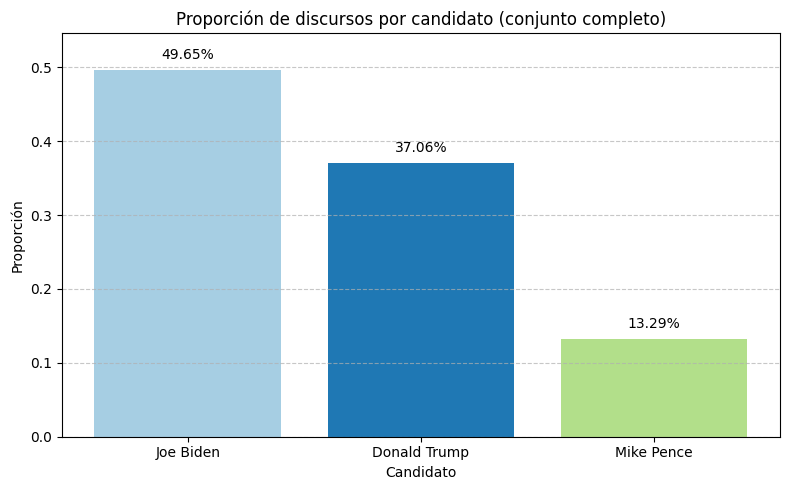

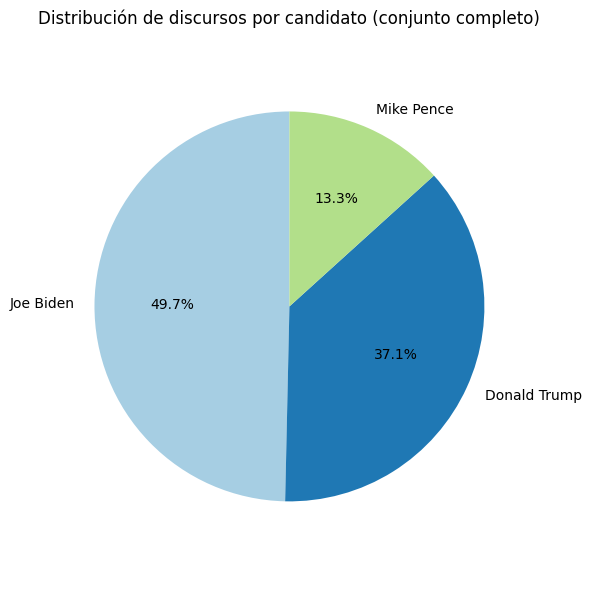

In [6]:
import matplotlib.pyplot as plt

# Obtener proporciones por candidato
speaker_props = df_speeches_top_3["speaker"].value_counts(normalize=True)

# Gráfico de barras con porcentaje encima
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(speaker_props.index, speaker_props.values, color=plt.cm.Paired(range(len(speaker_props))))
ax.set_title("Proporción de discursos por candidato (conjunto completo)")
ax.set_xlabel("Candidato")
ax.set_ylabel("Proporción")
ax.set_ylim(0, speaker_props.max() + 0.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar los porcentajes arriba de cada barra
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.2%}", 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Gráfico de torta
plt.figure(figsize=(6, 6))
plt.pie(speaker_props.values, labels=speaker_props.index, autopct='%1.1f%%', 
        startangle=90, colors=plt.cm.Paired(range(len(speaker_props))))
plt.title("Distribución de discursos por candidato (conjunto completo)")
plt.axis('equal')  # Para que sea un círculo perfecto
plt.tight_layout()
plt.show()

## Parte 1: Dataset y representación numérica de texto

In [9]:

from sklearn.model_selection import train_test_split

# Definir variables predictoras (texto limpio) y etiquetas (candidato)
X = df_speeches_top_3["CleanText"]
y = df_speeches_top_3["speaker"]

# División 70% dev, 30% test
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Mostrar tamaños resultantes
print(f"Tamaño conjunto de desarrollo (dev): {X_dev.shape[0]}")
print(f"Tamaño conjunto de prueba (test): {X_test.shape[0]}")


Tamaño conjunto de desarrollo (dev): 100
Tamaño conjunto de prueba (test): 43


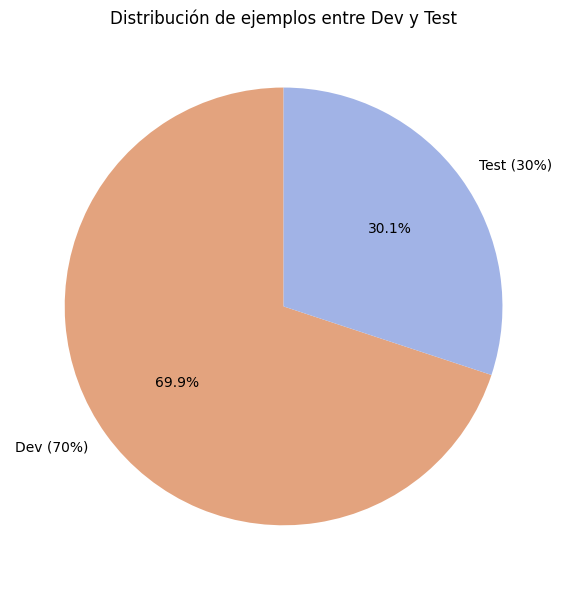

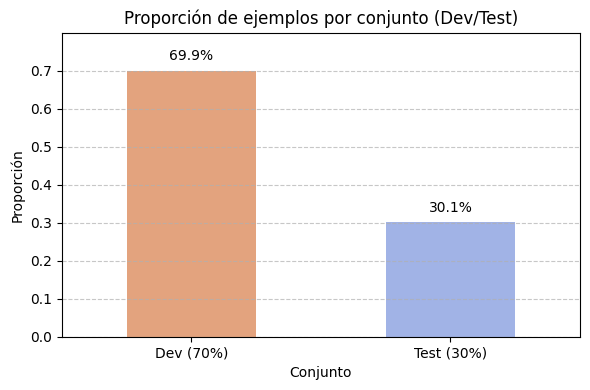

In [15]:
# Cantidades de ejemplos en cada conjunto
sizes = [len(X_dev), len(X_test)]
labels = ['Dev (70%)', 'Test (30%)']
colors = ["#E3A37E", "#A1B3E6"]  # Celeste para dev, verde claro para test

# ---------------------------
# Gráfico de torta
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Distribución de ejemplos entre Dev y Test")
plt.tight_layout()
plt.show()

# ---------------------------
# Gráfico de barra normalizada
split_counts = pd.Series({
    'Dev (70%)': sizes[0],
    'Test (30%)': sizes[1]
})
split_props = split_counts / split_counts.sum()  # Normalizar a 1

# Graficar barra
ax = split_props.plot(kind='bar', color=colors, figsize=(6, 4), rot=0)
plt.title("Proporción de ejemplos por conjunto (Dev/Test)")
plt.xlabel("Conjunto")
plt.ylabel("Proporción")
plt.ylim(0, split_props.max() + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar porcentajes arriba de cada barra
for i, val in enumerate(split_props):
    plt.text(i, val + 0.02, f'{val:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

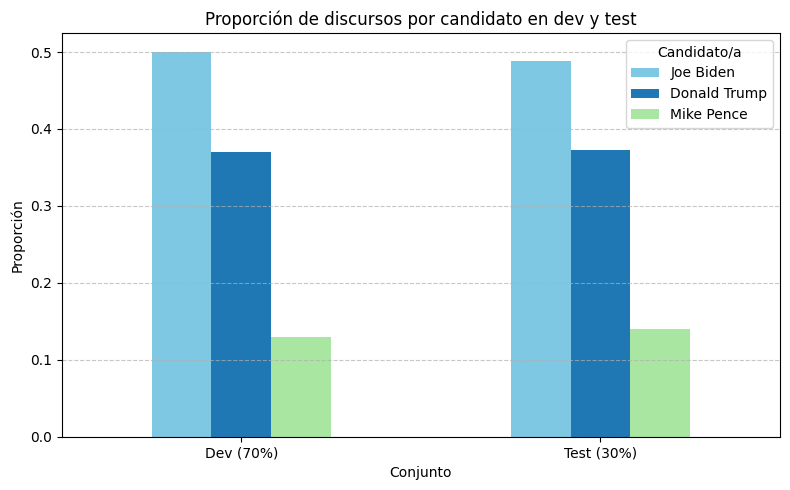

In [ ]:
# Contar proporciones por clase en cada conjunto
dev_counts = y_dev.value_counts(normalize=True)
test_counts = y_test.value_counts(normalize=True)

# Crear DataFrame combinado
proportion_df = pd.DataFrame({
    "Dev (70%)": dev_counts,
    "Test (30%)": test_counts
}).T

# Ordenar candidatos según frecuencia total (suma de dev y test)
total_counts = dev_counts.add(test_counts, fill_value=0)
ordered_candidates = total_counts.sort_values(ascending=False).index.tolist()

# Colores personalizados: más frecuente → celeste, medio → azul, menos → verde claro
custom_colors = {
    ordered_candidates[0]: "#7EC8E3",   # celeste
    ordered_candidates[1]: "#1F77B4",   # azul
    ordered_candidates[2]: "#A8E6A1"    # verde manzana claro
}

# Asignar colores en orden correcto
bar_colors = [custom_colors[cand] for cand in proportion_df.columns]

# Graficar
ax = proportion_df.plot(kind="bar", figsize=(8, 5), rot=0, color=bar_colors)
plt.title("Proporción de discursos por candidato en dev y test")
plt.xlabel("Conjunto")
plt.ylabel("Proporción")
plt.legend(title="Candidato/a")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

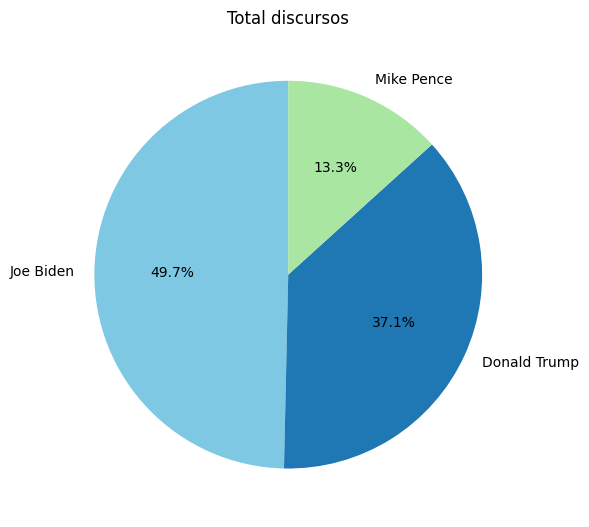

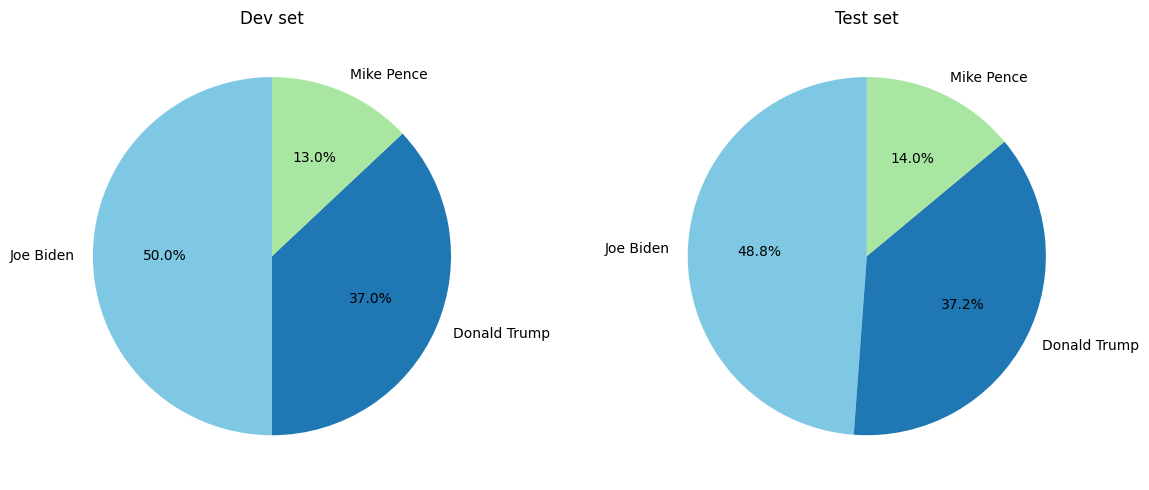

In [11]:
# Obtener los nombres de los candidatos ordenados por cantidad total
total_counts = y.value_counts()
ordered_candidates = total_counts.index.tolist()

# Definir colores personalizados según frecuencia
custom_colors = {
    ordered_candidates[0]: "#7EC8E3",   # celeste
    ordered_candidates[1]: "#1F77B4",   # azul
    ordered_candidates[2]: "#A8E6A1"    # verde manzana claro
}

# Lista de colores en orden para cada gráfico
colors_total = [custom_colors[c] for c in total_counts.index]
colors_dev = [custom_colors[c] for c in y_dev.value_counts().index]
colors_test = [custom_colors[c] for c in y_test.value_counts().index]

# -------- Gráfico de torta total (solo) --------
plt.figure(figsize=(6, 6))
plt.pie(total_counts, labels=total_counts.index, autopct='%1.1f%%', startangle=90, colors=colors_total)
plt.title('Total discursos')
plt.tight_layout()
plt.show()

# -------- Gráficos de torta dev y test (juntos) --------
dev_counts = y_dev.value_counts()
test_counts = y_test.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dev
axes[0].pie(dev_counts, labels=dev_counts.index, autopct='%1.1f%%', startangle=90, colors=colors_dev)
axes[0].set_title('Dev set')

# Test
axes[1].pie(test_counts, labels=test_counts.index, autopct='%1.1f%%', startangle=90, colors=colors_test)
axes[1].set_title('Test set')

plt.tight_layout()
plt.show()

Hasta aca separacion de datos, graficas etc.


Ahora comienza el codigo.

In [ ]:
# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.

#from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Inicializar vectorizador BoW
vectorizer = CountVectorizer()

# Ajustar al conjunto de desarrollo y transformar
X_dev_bow = vectorizer.fit_transform(X_dev)
X_test_bow = vectorizer.transform(X_test)

# Aplicar TF-IDF sobre la matriz BoW
tfidf = TfidfTransformer()
X_dev_tfidf = tfidf.fit_transform(X_dev_bow)
X_test_tfidf = tfidf.transform(X_test_bow)

# Mostrar dimensiones de las matrices
print('---------------------------------------------------------------')
print(f"BoW shape (dev): {X_dev_bow.shape}")
print(f"TF-IDF shape (dev): {X_dev_tfidf.shape}")

print(f"\nNúmero total de palabras únicas: {len(vectorizer.get_feature_names_out())}")
print('---------------------------------------------------------------')

# ----------------------------
# 4. Analizar la sparsidad
# ----------------------------
# Porcentaje de celdas con datos (densidad)
nnz = X_dev_bow.nnz  # cantidad de valores no cero
total = X_dev_bow.shape[0] * X_dev_bow.shape[1]
densidad = nnz / total * 100

print(f"Densidad matriz BoW (dev): {densidad:.4f}%")

# ----------------------------
# 5. Visualizar un ejemplo (opcional, solo para pocos textos)
# ----------------------------
# Mostrar las primeras 2 filas de la matriz BoW con nombres de palabras
vocab = vectorizer.get_feature_names_out()
ejemplo = X_dev_bow[:2].toarray()

df_ejemplo = pd.DataFrame(ejemplo, columns=vocab)
# Mostramos solo columnas con algún valor
print("Primeros discursos como BoW:")
print(df_ejemplo.loc[:, (df_ejemplo != 0).any(axis=0)])

BoW shape (dev): (100, 13669)
TF-IDF shape (dev): (100, 13669)

Número total de palabras únicas: 13669
Densidad matriz BoW (dev): 9.0451%
Primeros discursos como BoW:
   00  000  01  02  03  04  05  06  07  08  ...  yes  yet  yoga  york  you  \
0   0    0   1   1   1   1   1   2   0   0  ...    0    0     0     0   21   
1  15   14  66   4   8  10   7   5   5  10  ...    4    1     2    10  345   

   young  your  yourself  youth  zero  
0      0     2         0      0     0  
1      1    68         1      1     1  

[2 rows x 1984 columns]


podemos ver que hay 13669 palabras unicas. es un vocabulario relativamente grande

la densidad de la matriz es del 9.045% estamos trabajando con una matriz muy dispersa. cada discurso usa un peque;o subconjunto de todas las palabras q se usan

que la matriz sea dispersa modelos como naive bayes o svm funcionaran bien
aunque en terminos de eficiencia computacional y espacio en memoria, conviene mantener el vocabulario bajo control 



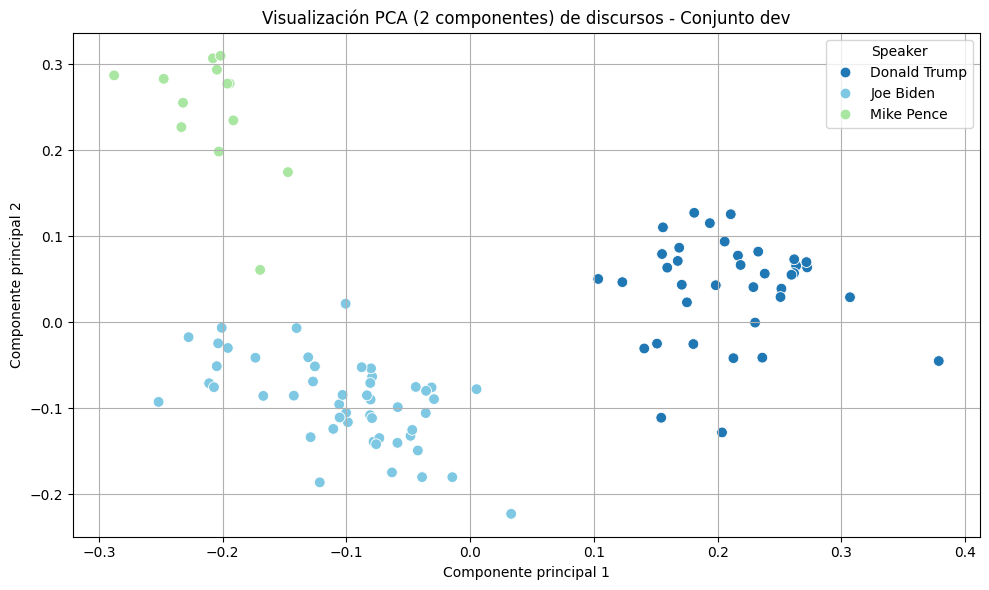

In [18]:
# Reducir a 2 dimensiones usando PCA
pca = PCA(n_components=2)
X_dev_pca = pca.fit_transform(X_dev_tfidf.toarray())

# Crear DataFrame para graficar
pca_df = pd.DataFrame({
    'PCA1': X_dev_pca[:, 0],
    'PCA2': X_dev_pca[:, 1],
    'Speaker': y_dev.values
})

# Definir colores personalizados para los candidatos
ordered_candidates = y_dev.value_counts().index.tolist()  # ordenados por frecuencia
custom_palette = {
    ordered_candidates[0]: "#7EC8E3",  # celeste
    ordered_candidates[1]: "#1F77B4",  # azul
    ordered_candidates[2]: "#A8E6A1"   # verde manzana
}

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Speaker', palette=custom_palette, s=60)
plt.title('Visualización PCA (2 componentes) de discursos - Conjunto dev')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# Obtener nombres de palabras (features)
feature_names = vectorizer.get_feature_names_out()

# Número de palabras más importantes a mostrar por componente
top_n = 10

for i, comp in enumerate(pca.components_[:2]):  # solo los dos primeros componentes
    indices = comp.argsort()[::-1][:top_n]
    top_words = [(feature_names[idx], comp[idx]) for idx in indices]
    print(f"\nTop palabras del componente {i+1}:")
    for word, weight in top_words:
        print(f"{word}: {weight:.4f}")


Top palabras del componente 1:
they: 0.3766
it: 0.3134
you: 0.2718
donald: 0.1892
trump: 0.1742
he: 0.1307
we: 0.1231
re: 0.1188
very: 0.1018
don: 0.1016

Top palabras del componente 2:
pence: 0.3505
mike: 0.3097
and: 0.2154
trump: 0.1761
we: 0.1697
donald: 0.1633
years: 0.1516
president: 0.1443
of: 0.1383
our: 0.1336


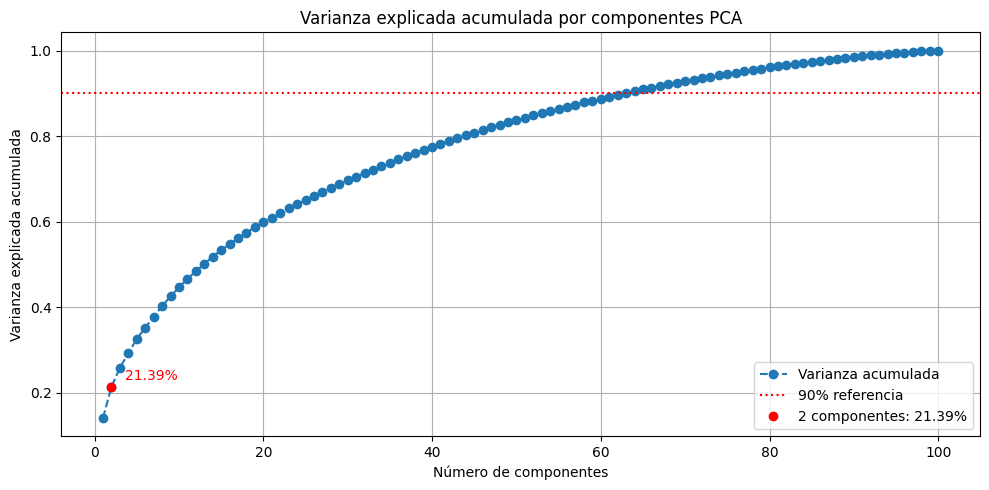

In [20]:
# PCA completo para calcular todas las componentes
pca_full = PCA()
pca_full.fit(X_dev_tfidf.toarray())

# Calcular varianza explicada y acumulada
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Componentes a resaltar
target_components = 2
var_target = cumulative_variance[target_components - 1]

# Visualización
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--', label="Varianza acumulada")
plt.axhline(y=0.90, color='red', linestyle=':', label="90% referencia")

# Punto en rojo para 2 componentes
plt.plot(target_components, var_target, 'ro', label=f"2 componentes: {var_target:.2%}")
plt.annotate(f"{var_target:.2%}", 
             (target_components, var_target), 
             textcoords="offset points", 
             xytext=(10, 5), 
             ha='left', 
             color='red')

plt.title('Varianza explicada acumulada por componentes PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Parte 2: Entrenamiento y Evaluación de Modelos


C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.488
Precision (macro): 0.163
Recall (macro): 0.333
-------------------------------------------------------


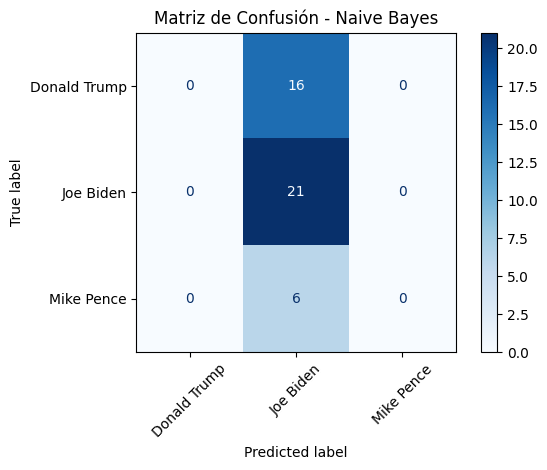

In [22]:
# 1: Entrene el modelo Multinomial Naive Bayes, luego utilícelo para predecir sobre el conjunto de test, y reporte el valor de accuracy y la matriz de confusión. Reporte el valor de precision y recall para cada candidato. 
# Calcular matriz de confusión Sugerencia: utilice el método from_predictions de ConfusionMatrixDisplay para realizar la matriz.


#from sklearn.naive_bayes import MultinomialNB
#from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Entrenar modelo con TF-IDF del conjunto de desarrollo
nb_model = MultinomialNB()
nb_model.fit(X_dev_tfidf, y_dev)

# Predecir sobre el conjunto de prueba
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluar métricas
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='macro')
recall = recall_score(y_test, y_pred_nb, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")
print('-------------------------------------------------------')
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de Confusión - Naive Bayes')
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\juanp\AppData\Local\Temp\ipykernel_22344\2594208809.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='param_alpha', y='mean_test_score', data=results_df, inner="quart", palette="muted")


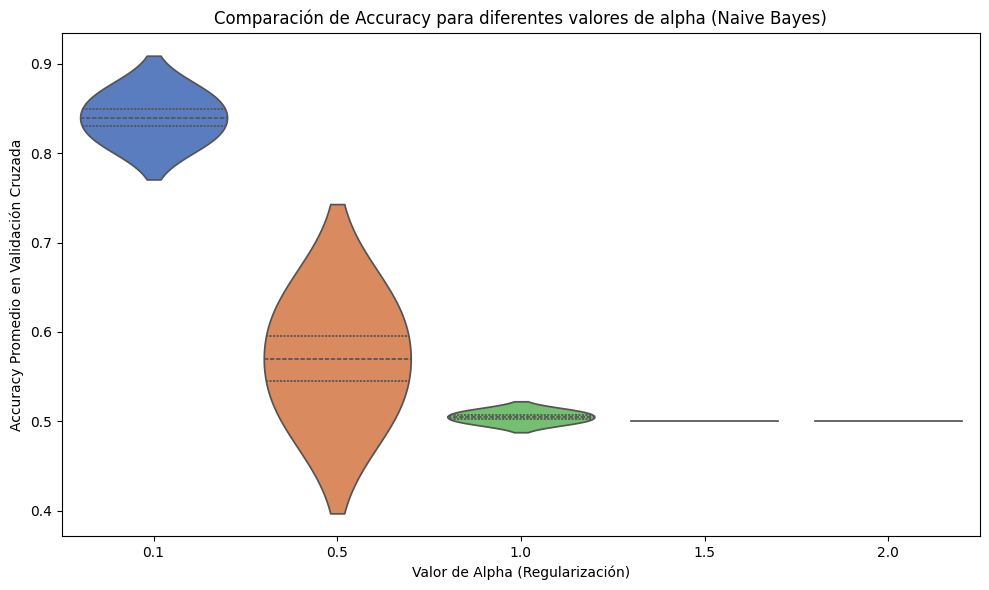

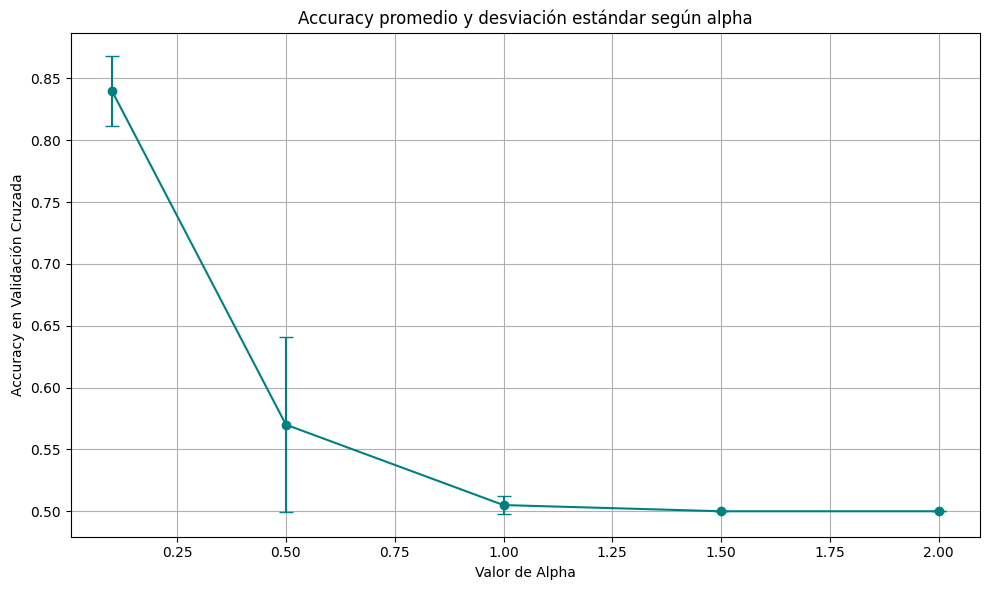


Resultados por valor de alpha:
 Alpha |  Accuracy Promedio |   Desviación Estándar
--------------------------------------------------
   0.1 |             0.8400 |                0.0283
   0.5 |             0.5700 |                0.0707
   1.0 |             0.5050 |                0.0071
   1.5 |             0.5000 |                0.0000
   2.0 |             0.5000 |                0.0000

Mejores parámetros encontrados: {'alpha': 0.1, 'fit_prior': False}
Mejor Accuracy: 0.8600


In [27]:
from sklearn.model_selection import GridSearchCV

# 1. Definir el modelo
nb_model = MultinomialNB()

# 2. Parámetros a explorar
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0],
    'fit_prior': [True, False]
}

# 3. Grid search con validación cruzada
grid_search = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='accuracy',
    return_train_score=True,
    verbose=1
)

# 4. Ajustar modelo
grid_search.fit(X_dev_tfidf, y_dev)

# 5. Resultados
results_df = pd.DataFrame(grid_search.cv_results_)

# === GRÁFICO DE VIOLÍN ===
plt.figure(figsize=(10, 6))
sns.violinplot(x='param_alpha', y='mean_test_score', data=results_df, inner="quart", palette="muted")
plt.title('Comparación de Accuracy para diferentes valores de alpha (Naive Bayes)')
plt.xlabel('Valor de Alpha (Regularización)')
plt.ylabel('Accuracy Promedio en Validación Cruzada')
plt.tight_layout()
plt.show()

# === GRÁFICO DE LÍNEAS CON BARRAS DE ERROR ===
grouped = results_df.groupby('param_alpha')['mean_test_score']
alpha_vals = grouped.mean().index
mean_scores = grouped.mean().values
std_scores = grouped.std().values

plt.figure(figsize=(10, 6))
plt.errorbar(alpha_vals, mean_scores, yerr=std_scores, fmt='-o', capsize=5, color='teal')
plt.title('Accuracy promedio y desviación estándar según alpha')
plt.xlabel('Valor de Alpha')
plt.ylabel('Accuracy en Validación Cruzada')
plt.grid(True)
plt.tight_layout()
plt.show()

# === Mostrar tabla resumen de métricas ===
print("\nResultados por valor de alpha:")
print(f"{'Alpha':>6} | {'Accuracy Promedio':>18} | {'Desviación Estándar':>21}")
print("-" * 50)
for a, acc, std in zip(alpha_vals, mean_scores, std_scores):
    print(f"{a:6.1f} | {acc:18.4f} | {std:21.4f}")

# === Mejor resultado ===
print("\nMejores parámetros encontrados:", grid_search.best_params_)
print(f"Mejor Accuracy: {grid_search.best_score_:.4f}")

Accuracy: 0.837
Precision (macro): 0.583
Recall (macro): 0.646
-------------------------------------------------------


C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


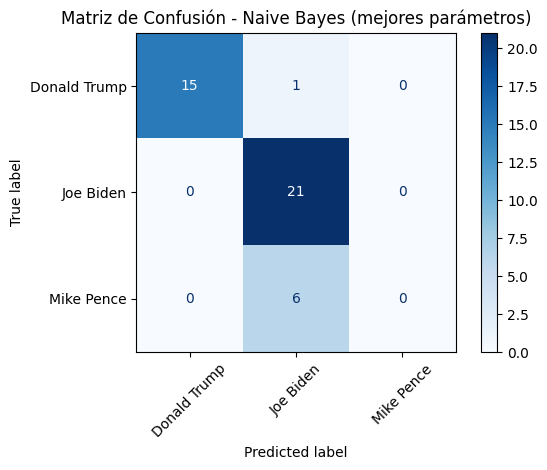

In [30]:
# Entrenar modelo Naive Bayes con mejores hiperparámetros
nb_model = MultinomialNB(alpha=0.1, fit_prior=False)
nb_model.fit(X_dev_tfidf, y_dev)

# Predecir sobre el conjunto de prueba
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluar métricas
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='macro')
recall = recall_score(y_test, y_pred_nb, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")
print('-------------------------------------------------------')

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de Confusión - Naive Bayes (mejores parámetros)')
plt.tight_layout()
plt.show()

Accuracy: 0.837
Precision (macro): 0.583
Recall (macro): 0.646


C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


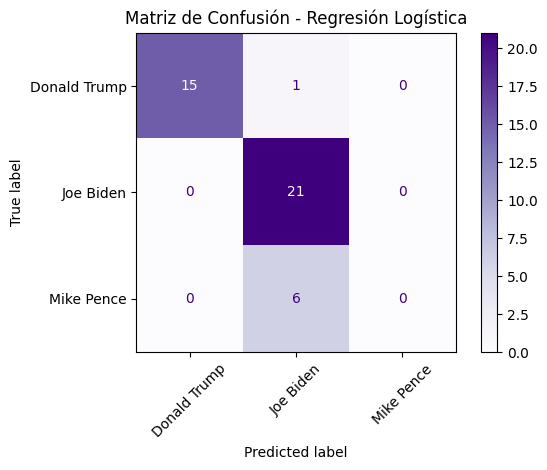

In [31]:
# 2: Implemente una búsqueda de hiperparámetros usando GridSearchCV.

# Genere una visualización que permita comparar las métricas (e.g: accuracy) de los distintos modelos entrenados, viendo el valor promedio y variabilidad de las mismas en todos los splits (e.g: en un gráfico de violín).


#from sklearn.linear_model import LogisticRegression

# Entrenar modelo de regresión logística
log_model = LogisticRegression(solver='liblinear', random_state=42)
log_model.fit(X_dev_tfidf, y_dev)

# Predecir sobre test
y_pred_log = log_model.predict(X_test_tfidf)

# Evaluar métricas
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average='macro')
recall = recall_score(y_test, y_pred_log, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_log, labels=log_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_model.classes_)
disp.plot(cmap='Purples', xticks_rotation=45)
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()


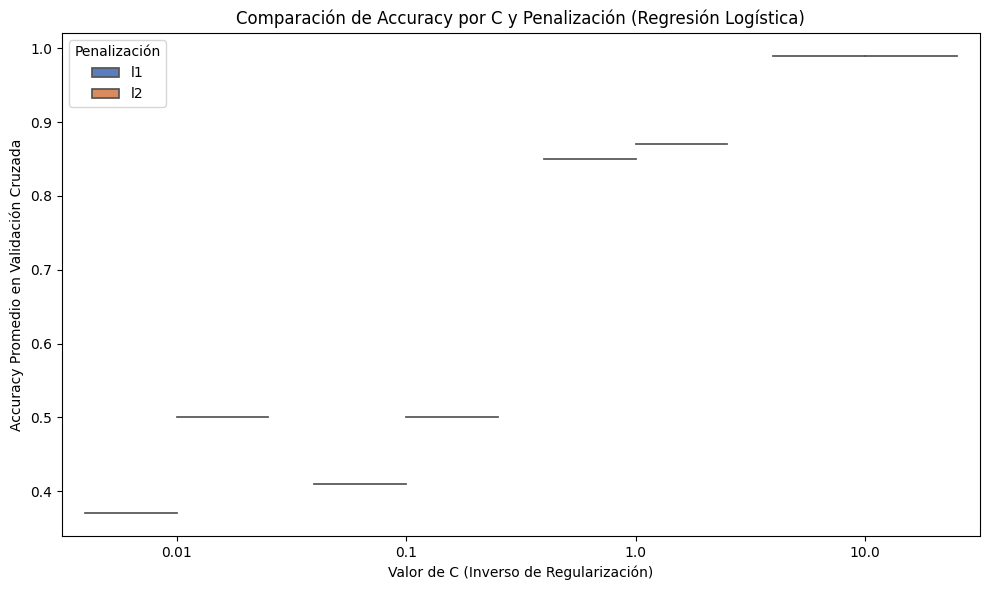

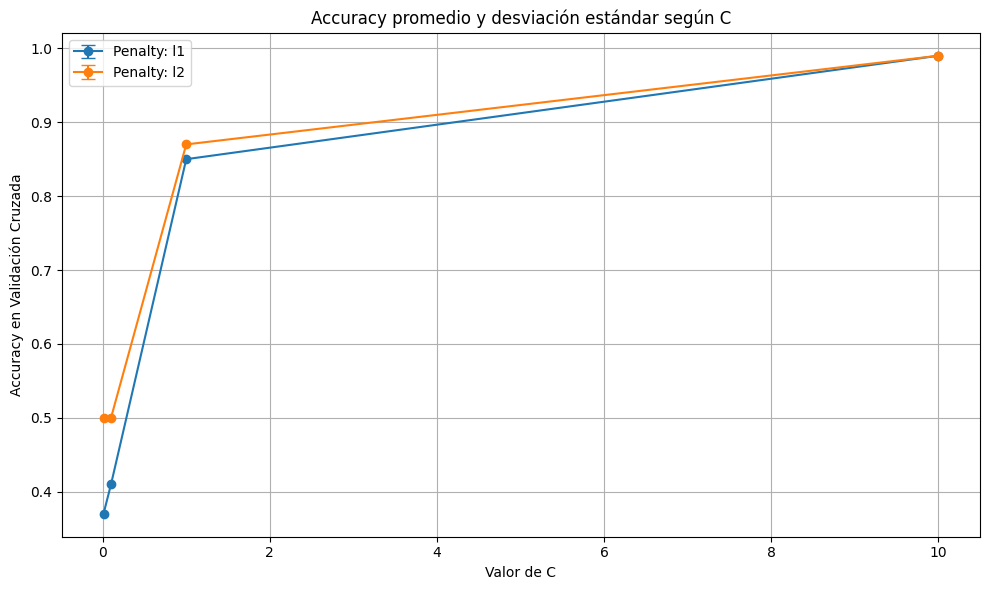


Resultados por combinación de C y penalización:
     C | Penalización |  Accuracy Promedio |   Desviación Estándar
----------------------------------------------------------------------
  0.01 | l1           |             0.3700 |                   nan
  0.01 | l2           |             0.5000 |                   nan
  0.10 | l1           |             0.4100 |                   nan
  0.10 | l2           |             0.5000 |                   nan
  1.00 | l1           |             0.8500 |                   nan
  1.00 | l2           |             0.8700 |                   nan
 10.00 | l1           |             0.9900 |                   nan
 10.00 | l2           |             0.9900 |                   nan

Mejores hiperparámetros encontrados: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor Accuracy en validación cruzada: 0.9900


In [33]:
# 3: Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación). Reporte el valor final de las métricas y la matriz de confusión.


#from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # compatible con l1 y l2
}

# Configurar búsqueda con validación cruzada
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Ajustar al conjunto de desarrollo
grid_search.fit(X_dev_tfidf, y_dev)

# === Convertir resultados a DataFrame ===
results_df = pd.DataFrame(grid_search.cv_results_)

# === GRÁFICO DE VIOLÍN ===
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='param_C', 
    y='mean_test_score', 
    hue='param_penalty', 
    data=results_df, 
    inner="quart", 
    palette="muted",
    split=True
)
plt.title('Comparación de Accuracy por C y Penalización (Regresión Logística)')
plt.xlabel('Valor de C (Inverso de Regularización)')
plt.ylabel('Accuracy Promedio en Validación Cruzada')
plt.legend(title="Penalización")
plt.tight_layout()
plt.show()

# === GRÁFICO DE LÍNEAS CON BARRAS DE ERROR ===
# Agrupar por C y penalty
grouped = results_df.groupby(['param_C', 'param_penalty'])['mean_test_score']
mean_scores = grouped.mean()
std_scores = grouped.std()

# Gráfico para cada penalización por separado
plt.figure(figsize=(10, 6))
for penalty in ['l1', 'l2']:
    subset = mean_scores[mean_scores.index.get_level_values('param_penalty') == penalty]
    std_subset = std_scores[std_scores.index.get_level_values('param_penalty') == penalty]
    c_vals = subset.index.get_level_values('param_C')
    plt.errorbar(c_vals, subset.values, yerr=std_subset.values, fmt='-o', capsize=5, label=f'Penalty: {penalty}')

plt.title('Accuracy promedio y desviación estándar según C')
plt.xlabel('Valor de C')
plt.ylabel('Accuracy en Validación Cruzada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Mostrar tabla resumen de métricas ===
print("\nResultados por combinación de C y penalización:")
print(f"{'C':>6} | {'Penalización':>12} | {'Accuracy Promedio':>18} | {'Desviación Estándar':>21}")
print("-" * 70)
for (c, penalty), acc in mean_scores.items():
    std = std_scores[(c, penalty)]
    print(f"{c:6.2f} | {penalty:12} | {acc:18.4f} | {std:21.4f}")

# === Reportar mejor combinación ===
print("\nMejores hiperparámetros encontrados:", grid_search.best_params_)
print(f"Mejor Accuracy en validación cruzada: {grid_search.best_score_:.4f}")


Evaluación del mejor modelo en conjunto de prueba:
Accuracy: 1.000
Precision (macro): 1.000
Recall (macro): 1.000


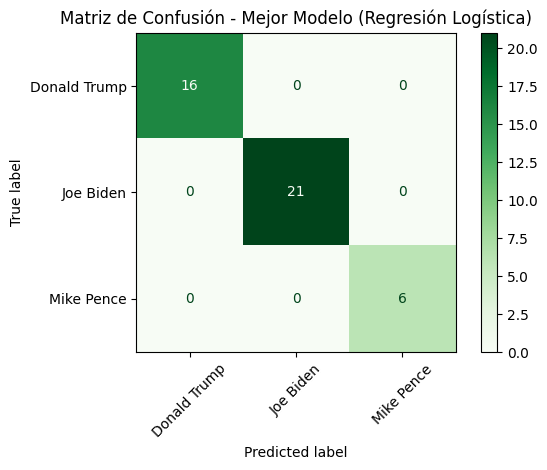

In [14]:
# 4: Evalúe con validación cruzada al menos un modelo más (dentro de scikit-learn) aparte de Multinomial Naive Bayes para clasificar el texto utilizando las mismas features de texto.


# Predecir sobre el conjunto de prueba con el mejor estimador
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_tfidf)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='macro')
recall = recall_score(y_test, y_pred_best, average='macro')

print("Evaluación del mejor modelo en conjunto de prueba:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Greens', xticks_rotation=45)
plt.title('Matriz de Confusión - Mejor Modelo (Regresión Logística)')
plt.tight_layout()
plt.show()


In [73]:
cambiar de speaker

SyntaxError: invalid syntax (86939335.py, line 1)

In [58]:
# 5: Evalúe el problema cambiando al menos un candidato. En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.



# Obtener los 4 candidatos con más discursos
top_4 = df_speeches_clean["speaker"].value_counts().head(4).index.tolist()

# Reemplazar el tercero por el cuarto
candidatos_modificados = [top_4[0], top_4[1], top_4[3]]  # Ejemplo: [Trump, Biden, Bernie Sanders]
print("Candidatos seleccionados (con reemplazo):", candidatos_modificados)

# Filtrar dataset con estos 3 candidatos
df_alt = df_speeches_clean[df_speeches_clean["speaker"].isin(candidatos_modificados)]

# Variables predictoras y etiquetas
X_alt = df_alt["CleanText"]
y_alt = df_alt["speaker"]

# División dev/test (70/30) con estratificación
X_dev_alt, X_test_alt, y_dev_alt, y_test_alt = train_test_split(
    X_alt, y_alt, test_size=0.3, random_state=42, stratify=y_alt
)

# Verificar formas
print(X_alt.shape, y_alt.shape)
print(X_dev_alt.shape, y_dev_alt.shape)
print(X_test_alt.shape, y_test_alt.shape)

# Mostrar distribución de clases
print("Distribución en conjunto de desarrollo (dev):")
print(y_dev_alt.value_counts())

print("\nDistribución en conjunto de prueba (test):")
print(y_test_alt.value_counts())


Candidatos seleccionados (con reemplazo): ['Joe Biden', 'Donald Trump', 'Bernie Sanders']
(140,) (140,)
(98,) (98,)
(42,) (42,)
Distribución en conjunto de desarrollo (dev):
speaker
Joe Biden         50
Donald Trump      37
Bernie Sanders    11
Name: count, dtype: int64

Distribución en conjunto de prueba (test):
speaker
Joe Biden         21
Donald Trump      16
Bernie Sanders     5
Name: count, dtype: int64


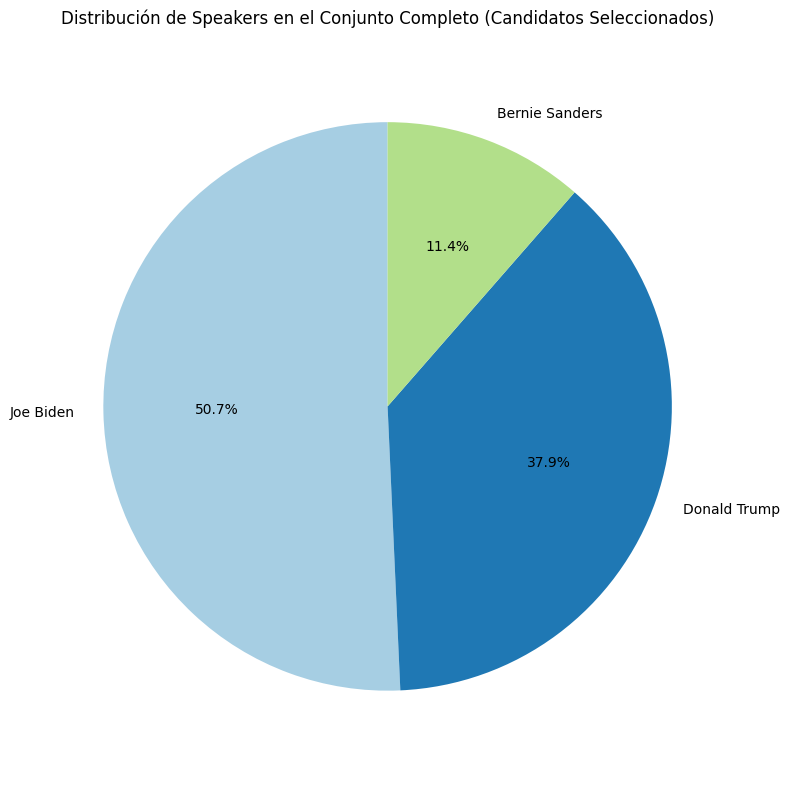

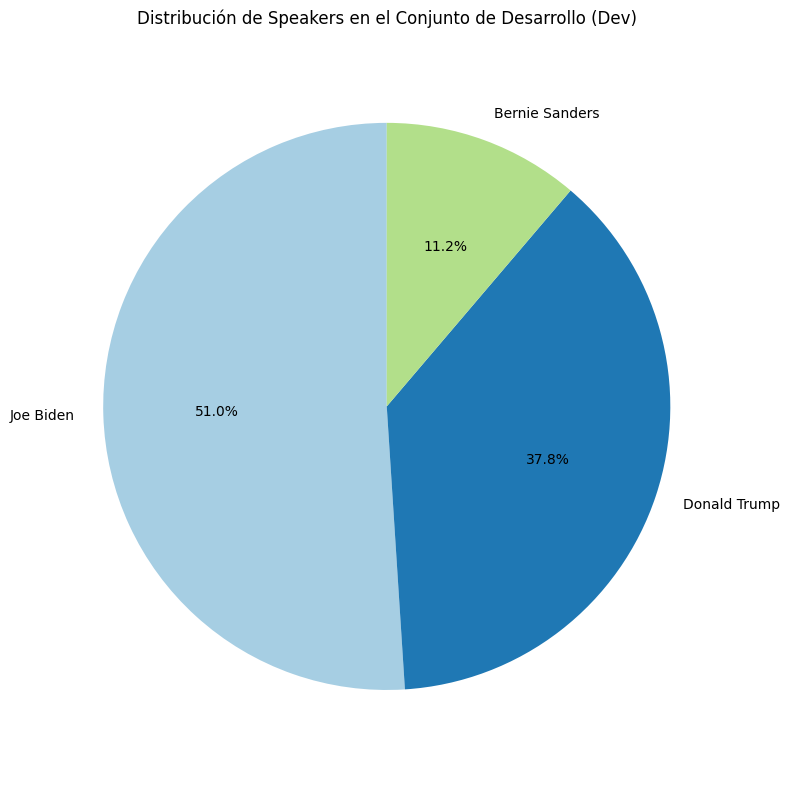

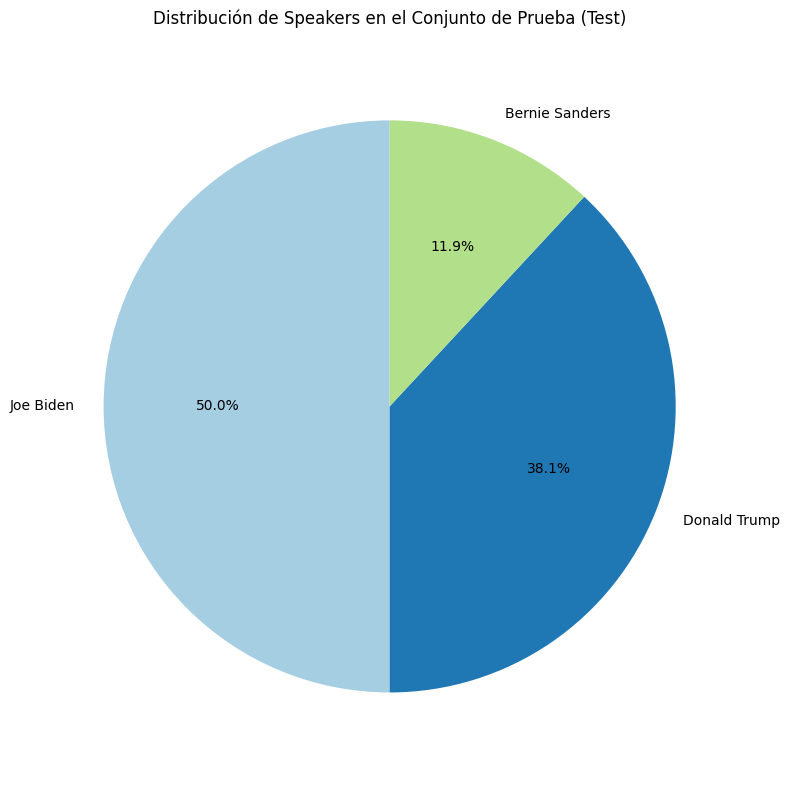

In [59]:
# 1. Distribución de los candidatos seleccionados en el conjunto completo
speaker_counts_full = df_alt["speaker"].value_counts()
speaker_percentages_full = speaker_counts_full / speaker_counts_full.sum() * 100

# Gráfico de torta para el conjunto completo con los candidatos seleccionados
plt.figure(figsize=(8, 8))
plt.pie(speaker_percentages_full, labels=speaker_percentages_full.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Distribución de Speakers en el Conjunto Completo (Candidatos Seleccionados)")
plt.axis('equal')  # Asegura que la torta sea un círculo
plt.tight_layout()
plt.show()

# 2. Distribución en el conjunto de desarrollo (dev)
speaker_counts_dev = y_dev_alt.value_counts()
speaker_percentages_dev = speaker_counts_dev / speaker_counts_dev.sum() * 100

# Gráfico de torta para el conjunto de desarrollo (dev)
plt.figure(figsize=(8, 8))
plt.pie(speaker_percentages_dev, labels=speaker_percentages_dev.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Distribución de Speakers en el Conjunto de Desarrollo (Dev)")
plt.axis('equal')
plt.tight_layout()
plt.show()

# 3. Distribución en el conjunto de prueba (test)
speaker_counts_test = y_test_alt.value_counts()
speaker_percentages_test = speaker_counts_test / speaker_counts_test.sum() * 100

# Gráfico de torta para el conjunto de prueba (test)
plt.figure(figsize=(8, 8))
plt.pie(speaker_percentages_test, labels=speaker_percentages_test.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Distribución de Speakers en el Conjunto de Prueba (Test)")
plt.axis('equal')
plt.tight_layout()
plt.show()

In [60]:
# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.

#from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# Inicializar vectorizador BoW
vectorizer_alt = CountVectorizer()

# Ajustar al conjunto de desarrollo y transformar
X_dev_bow_alt = vectorizer_alt.fit_transform(X_dev_alt)
X_test_bow_alt = vectorizer_alt.transform(X_test_alt)

# Aplicar TF-IDF sobre la matriz BoW
tfidf_alt = TfidfTransformer()
X_dev_tfidf_alt = tfidf.fit_transform(X_dev_bow_alt)
X_test_tfidf_alt = tfidf.transform(X_test_bow_alt)

# Mostrar dimensiones de las matrices
print('---------------------------------------------------------------')
print(f"BoW shape (dev): {X_dev_bow_alt.shape}")
print(f"TF-IDF shape (dev): {X_dev_tfidf_alt.shape}")

print(f"\nNúmero total de palabras únicas: {len(vectorizer_alt.get_feature_names_out())}")
print('---------------------------------------------------------------')

# ----------------------------
# 4. Analizar la sparsidad
# ----------------------------
# Porcentaje de celdas con datos (densidad)
nnz_alt = X_dev_bow_alt.nnz  # cantidad de valores no cero
total_alt = X_dev_bow_alt.shape[0] * X_dev_bow_alt.shape[1]
densidad_alt = nnz_alt / total_alt * 100

print(f"Densidad matriz BoW (dev): {densidad_alt:.4f}%")

# ----------------------------
# 5. Visualizar un ejemplo (opcional, solo para pocos textos)
# ----------------------------
# Mostrar las primeras 2 filas de la matriz BoW con nombres de palabras
vocab_alt = vectorizer_alt.get_feature_names_out()
ejemplo_alt = X_dev_bow_alt[:2].toarray()

df_ejemplo_alt = pd.DataFrame(ejemplo_alt, columns=vocab_alt)
# Mostramos solo columnas con algún valor
print("Primeros discursos como BoW:")
print(df_ejemplo_alt.loc[:, (df_ejemplo_alt != 0).any(axis=0)])

---------------------------------------------------------------
BoW shape (dev): (98, 13409)
TF-IDF shape (dev): (98, 13409)

Número total de palabras únicas: 13409
---------------------------------------------------------------
Densidad matriz BoW (dev): 9.3112%
Primeros discursos como BoW:
   00  000  01  02  03  04  05  06  07  08  ...  yes  yesterday  yet  york  \
0   8   13  54   5   4   1   4   2   4   4  ...    4          6    3    19   
1   0    2   2   0   1   0   2   3   1   5  ...    0          3    0     0   

   you  young  younger  your  zero  zones  
0  329      4        0    51     2      1  
1   17      1        2     2     0      0  

[2 rows x 2059 columns]


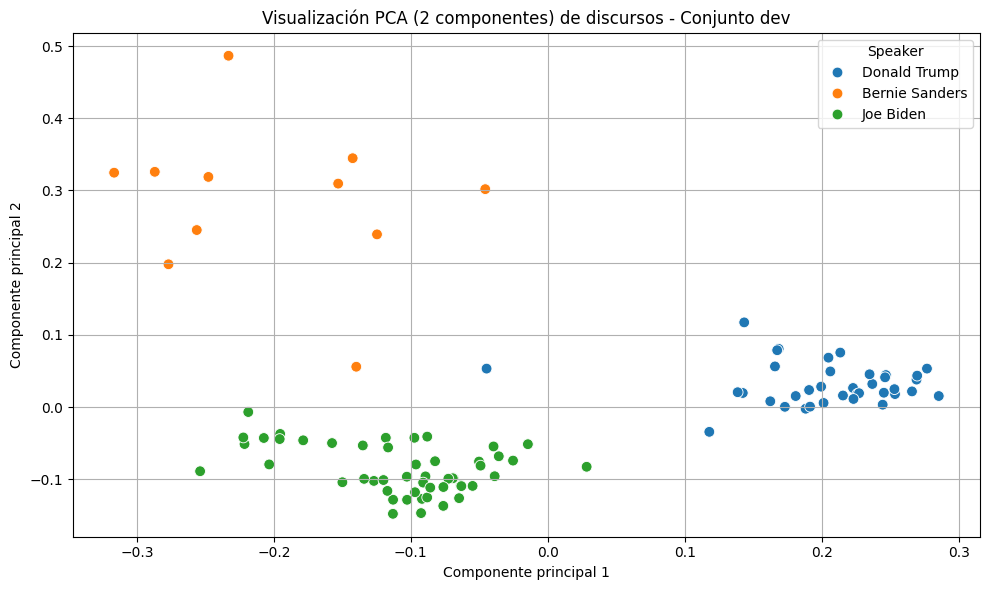

In [61]:
# Reducir a 2 dimensiones usando PCA
pca_alt = PCA(n_components=2)
X_dev_pca_alt = pca.fit_transform(X_dev_tfidf_alt.toarray())

# Crear DataFrame para graficar
pca_df_alt = pd.DataFrame({
    'PCA1': X_dev_pca_alt[:, 0],
    'PCA2': X_dev_pca_alt[:, 1],
    'Speaker': y_dev_alt.values
})

# Definir colores personalizados para los candidatos
ordered_candidates_alt = y_dev_alt.value_counts().index.tolist()  # ordenados por frecuencia
'''
custom_palette = {
    ordered_candidates[0]: "#7EC8E3",  # celeste
    ordered_candidates[1]: "#1F77B4",  # azul
    ordered_candidates[2]: "#A8E6A1"   # verde manzana
}
'''
# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df_alt, x='PCA1', y='PCA2', hue='Speaker',  s=60)
plt.title('Visualización PCA (2 componentes) de discursos - Conjunto dev')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
# Obtener nombres de palabras (features)
feature_names_alt = vectorizer_alt.get_feature_names_out()

# Número de palabras más importantes a mostrar por componente
top_n = 10

for i, comp in enumerate(pca.components_[:2]):  # solo los dos primeros componentes
    indices = comp.argsort()[::-1][:top_n]
    top_words = [(feature_names[idx], comp[idx]) for idx in indices]
    print(f"\nTop palabras del componente {i+1}:")
    for word, weight in top_words:
        print(f"{word}: {weight:.4f}")


Top palabras del componente 1:
systematic: 0.3549
interruptions: 0.2936
where: 0.2829
doctors: 0.2178
today: 0.1973
venezuela: 0.1935
hanger: 0.1665
queens: 0.1539
valuable: 0.1192
google: 0.1180

Top palabras del componente 2:
benefit: 0.4963
rocking: 0.3870
interference: 0.1252
april: 0.1157
doctors: 0.0936
today: 0.0917
voted: 0.0756
pardon: 0.0712
systematic: 0.0710
sweeping: 0.0702


Accuracy: 1.000
Precision (macro): 1.000
Recall (macro): 1.000


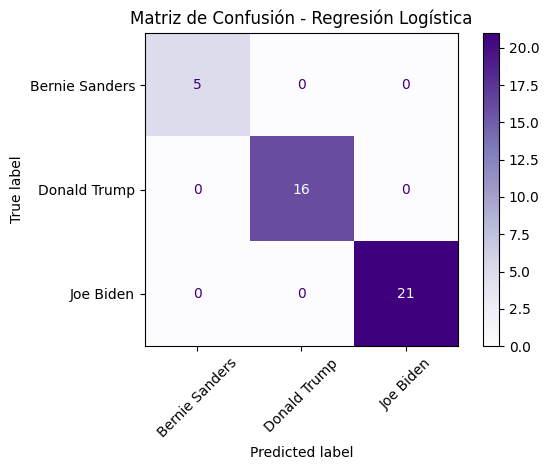

In [69]:
# Entrenar modelo de regresión logística
log_model_alt = LogisticRegression(solver='liblinear',C=10, penalty='l1', random_state=42)
log_model_alt.fit(X_dev_tfidf_alt, y_dev_alt)

# Predecir sobre test
y_pred_log_alt = log_model_alt.predict(X_test_tfidf_alt)

# Evaluar métricas
accuracy_alt = accuracy_score(y_test_alt, y_pred_log_alt)
precision_alt = precision_score(y_test_alt, y_pred_log_alt, average='macro')
recall_alt = recall_score(y_test_alt, y_pred_log_alt, average='macro')

print(f"Accuracy: {accuracy_alt:.3f}")
print(f"Precision (macro): {precision_alt:.3f}")
print(f"Recall (macro): {recall_alt:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test_alt, y_pred_log_alt, labels=log_model_alt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_model_alt.classes_)
disp.plot(cmap='Purples', xticks_rotation=45)
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()

opcional

In [83]:
top_3_candidates = df_speeches["speaker"].value_counts().head(3).index.tolist()
print(f"Top 3 candidatos: {top_3_candidates}")
print("---------------")

# Filtrar el DataFrame con solo esos candidatos
df_speeches_top_3 = df_speeches[df_speeches["speaker"].isin(top_3_candidates)]

paragraphs = []
labels = []

# Iterar sobre cada discurso de cada candidato
for idx, row in df_speeches_top_3.iterrows():
    # Dividir el discurso en párrafos utilizando el salto de línea '\n'
    paragraphs_in_speech = row['text'].split('\n')
    
    # Agregar cada párrafo y la etiqueta (candidato) a las listas
    for paragraph in paragraphs_in_speech:
        if paragraph.strip():  # Asegurarnos de que no estamos agregando párrafos vacíos
            paragraphs.append(paragraph)
            labels.append(row['speaker'])  # Asumimos que la columna 'speaker' tiene el nombre del candidato

# Crear un nuevo DataFrame con los párrafos y sus etiquetas
df_paragraphs = pd.DataFrame({'text': paragraphs, 'speaker': labels})

# Paso 2: Revisar los primeros párrafos para asegurarnos de que la división fue exitosa
print(df_paragraphs.head())

# Aplicar la limpieza a la columna 'text'
df_paragraphs['CleanText'] = clean_text(df_paragraphs, 'text')

# Crear copia para trabajar con datos limpios
df_paragraphs_clean = df_paragraphs.copy()

# Vista previa de los resultados
df_paragraphs_clean[['speaker', 'text', 'CleanText']].head()

df_paragraphs_clean

Top 3 candidatos: ['Joe Biden', 'Donald Trump', 'Mike Pence']
---------------
                                                text    speaker
0                               Joe Biden: (00:00)\r  Joe Biden
1  Hello, Michigan. Hi, how are you? What’s your ...  Joe Biden
2                               Joe Biden: (00:39)\r  Joe Biden
3  There’s not a better governor in the United St...  Joe Biden
4                               Joe Biden: (01:13)\r  Joe Biden


,text,speaker,CleanText
0,Joe Biden: (00:00)\r,Joe Biden,joe biden 00 00
1,"Hello, Michigan. Hi, how are you? What’s your ...",Joe Biden,hello michigan hi how are you what’s your name...
2,Joe Biden: (00:39)\r,Joe Biden,joe biden 00 39
3,There’s not a better governor in the United St...,Joe Biden,there’s not a better governor in the united st...
4,Joe Biden: (01:13)\r,Joe Biden,joe biden 01 13
...,...,...,...
22826,Proud citizens like you helped build this coun...,Donald Trump,proud citizens like you helped build this coun...
22827,audience: (01:01:17)\r,Donald Trump,audience 01 01 17
22828,[inaudible 01:01:21].\r,Donald Trump,inaudible 01 01 21]
22829,Donald Trump: (01:01:27)\r,Donald Trump,donald trump 01 01 27


Cantidad de párrafos por candidato:
speaker
Donald Trump    12007
Joe Biden        8814
Mike Pence       2010
Name: count, dtype: int64


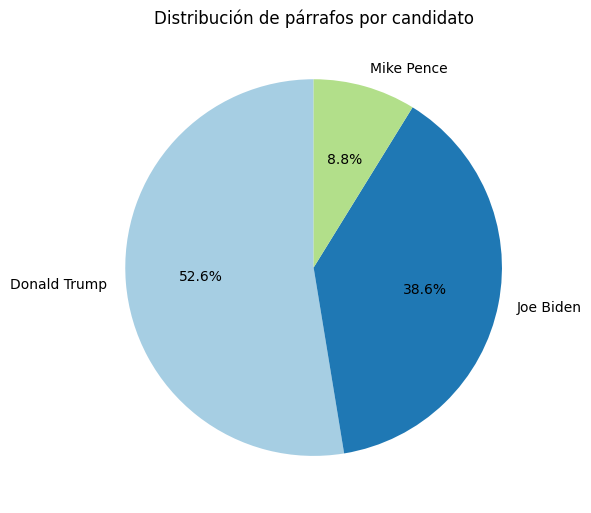

In [84]:
# Contar cuántos párrafos hay por candidato
paragraph_counts = df_paragraphs_clean['speaker'].value_counts()

# Mostrar los resultados
print("Cantidad de párrafos por candidato:")
print(paragraph_counts)

# Gráfico de torta
plt.figure(figsize=(6, 6))
colors = plt.cm.Paired.colors  # Colores bonitos y diferenciables

paragraph_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
)

plt.title('Distribución de párrafos por candidato')
plt.ylabel('')  # Ocultar el label del eje Y
plt.tight_layout()
plt.show()

C:\Users\juanp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


(6850,) (6850,) (6850,)
Accuracy: 0.905
Precision (macro): 0.910
Recall (macro): 0.873


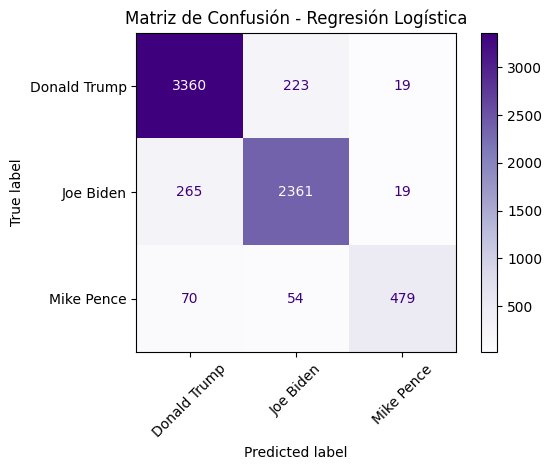

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Dividir el conjunto de datos en train y test
X = df_paragraphs_clean['text']
y = df_paragraphs_clean['speaker']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Aplicar TF-IDF al conjunto de entrenamiento
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))  # Se puede ajustar el n-grama aquí
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Entrenar modelo de regresión logística
log_model_alt = LogisticRegression(solver='liblinear',C=10, penalty='l1', random_state=42)
log_model_alt.fit(X_train_tfidf, y_train)

# Predecir sobre test
y_pred = log_model_alt.predict(X_test_tfidf)


print( X_test.shape, y_test.shape, y_pred.shape)

# Evaluar métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=log_model_alt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_model_alt.classes_)
disp.plot(cmap='Purples', xticks_rotation=45)
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()